# WenT Offline Analysis Review

Run all cells from the top after changing VIDEO/analysis ID. Existing saved outputs are historical until rerun. The pipeline preserves Vc/Vt amplitude; quality checks are engineering rules, not accuracy probabilities. Final exports include raw/processed traces, timestamps, ROI/calibration and provisional values. This notebook does not overwrite server results.

## Setup: Import Dependencies

In [1]:
import io
import json
import subprocess
import sys
import xml.etree.ElementTree as ET
from zipfile import ZipFile
import numpy as np
import matplotlib.pyplot as plt
import cv2
from pathlib import Path

# Add backend to path
backend_root = next((p for base in (Path.cwd(), *Path.cwd().parents) for p in (base, base / 'backend') if (p / 'app' / 'analysis').is_dir()), None)
if backend_root is None:
    raise RuntimeError('Run this notebook from the WenT repository or backend/tests.')
sys.path.insert(0, str(backend_root))
from app.analysis.pipeline import review_capture, capture_roi, review_video_file
from app.schemas import CaptureMetadata
from app.analysis.export import comparison_files, export_comparison_zip, export_zip

from app.analysis.video import read_video
from app.analysis.offline import (
    extract_area_signal, _gray_crop, _measurement_profile, _row_front_extents,
    _row_weighted_signal, _row_widths, _select_phase_rows, _subject_mask, _threshold,
)
from app.analysis.filtering import clean_respiratory_signal
from app.analysis.review import review_signal
from app.schemas import PixelRoi

# Configure matplotlib
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

## Multi-record comparison export

This prototype selects up to three saved videos, reruns the current production pipeline, and renders a paper-style summary table plus independently normalized overlaid waveforms. Edit `comparison_ids` after the automatic selection if you want specific runs.

In [ ]:
import sqlite3
import json
from datetime import datetime, timezone
from IPython.display import SVG, FileLink, display as show_output

# Automatically compare the current run with the newest other saved runs.
# Replace this list with exact IDs to control the report contents.
db_path = backend_root / 'data' / 'analyses.sqlite3'
with sqlite3.connect(db_path.resolve().as_uri() + '?mode=ro', uri=True) as conn:
    conn.row_factory = sqlite3.Row
    candidates = conn.execute(
        'SELECT id, video_path, declared_duration_ms, capture_metadata_json FROM analyses ORDER BY created_at DESC'
    ).fetchall()
comparison_ids = [row['id'] for row in candidates[:3]]
comparison_results = []
candidate_by_id = {row['id']: row for row in candidates}
for run_id in comparison_ids:
    row = candidate_by_id.get(run_id)
    if row is None:
        print('[SKIP] Missing database row:', run_id)
        continue
    run_video = backend_root / 'data' / row['video_path']
    if not run_video.is_file():
        print('[SKIP] Missing video:', run_video)
        continue
    try:
        run_result = review_video_file(run_video, json.loads(row['capture_metadata_json']), row['declared_duration_ms'])
    except Exception as error:
        print(f'[SKIP] {run_id}: {error}')
        continue
    run_result['analysis_id'] = run_id
    comparison_results.append(run_result)

if not comparison_results:
    raise RuntimeError('No saved run could be replayed for comparison.')
comparison_payload = comparison_files(comparison_results)
assert set(comparison_payload) == {'comparison.csv', 'comparison.json', 'comparison.svg', 'README.txt'}
comparison_json = json.loads(comparison_payload['comparison.json'])
assert comparison_json['export_version'] == 'went-comparison-export-v1'
assert len(comparison_json['summary']) == len(comparison_results)
assert len(comparison_json['normalized_traces']) == len(comparison_results)
for trace in comparison_json['normalized_traces']:
    scaled = [point['scaled_value'] for point in trace['points']]
    assert all(0.0 <= value <= 1.0 for value in scaled)
ET.fromstring(comparison_payload['comparison.svg'].decode('utf-8'))
comparison_bytes = export_comparison_zip(comparison_results)
with ZipFile(io.BytesIO(comparison_bytes)) as archive:
    assert set(archive.namelist()) == set(comparison_payload)
show_output(SVG(data=comparison_payload['comparison.svg'].decode('utf-8')))
comparison_export_dir = backend_root / 'data' / 'exports'
comparison_export_dir.mkdir(parents=True, exist_ok=True)
comparison_stamp = datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%S%fZ')
comparison_archive = comparison_export_dir / f'comparison-{len(comparison_results)}-runs-{comparison_stamp}.zip'
with comparison_archive.open('xb') as handle:
    handle.write(comparison_bytes)
print('Compared:', [item['analysis_id'] for item in comparison_results])
print('Each curve is scaled independently to 0-1 for shape comparison; Vc/Vt values remain unscaled.')
print('PASS: comparison JSON, scaled range, SVG XML, and ZIP members validated.')
show_output(FileLink(str(comparison_archive)))


## Step 1: Load Video

In [2]:
# Set an exact ID to reproduce one record, or keep None to use the newest video still on disk.
analysis_id = None
if analysis_id is None:
    with sqlite3.connect(db_path.resolve().as_uri() + '?mode=ro', uri=True) as conn:
        conn.row_factory = sqlite3.Row
        available = conn.execute(
            'SELECT id, video_path FROM analyses ORDER BY created_at DESC'
        ).fetchall()
    analysis_id = next((row['id'] for row in available if (backend_root / 'data' / row['video_path']).is_file()), None)
if analysis_id is None:
    raise FileNotFoundError('No saved analysis has a video file available for replay.')
video_path = backend_root / 'data' / 'videos' / f'{analysis_id}.webm'
if not video_path.is_file():
    raise FileNotFoundError(video_path)
print(video_path)


 Video loaded: 1280×720 @ 14.985014985014985 fps
   Frame count: 562


## Step 2: Define ROI

The saved `realtime_chest_roi` is a broad **search ROI**. Production analysis then selects one continuous upper/middle-thorax **measurement band** from repeated Vt motion with Vc support. White boxes below show the search ROI; green boxes/rows show what is actually summed.

In [3]:
import sqlite3
import json

db_path = backend_root / 'data' / 'analyses.sqlite3'
with sqlite3.connect(db_path.resolve().as_uri() + '?mode=ro', uri=True) as conn:
    conn.row_factory = sqlite3.Row
    saved = conn.execute('SELECT id, capture_metadata_json, declared_duration_ms FROM analyses WHERE id = ?', (analysis_id,)).fetchone()
if saved is None:
    raise ValueError('No metadata for this exact video ID. Supply its own capture metadata; do not use another recording.')
capture_metadata = json.loads(saved['capture_metadata_json'])
declared_duration_ms = saved['declared_duration_ms']
if 'video' in globals():
    video.close()
video = read_video(video_path, declared_duration_ms=declared_duration_ms)
metadata = CaptureMetadata.model_validate(capture_metadata)
roi, roi_source, roi_warnings = capture_roi(metadata, video)
print(f'Decoded: {video.width} x {video.height}, {video.fps:.2f} fps, {video.frame_count} frames')
print(f'Capture: {metadata.frame_width} x {metadata.frame_height}; search ROI: {roi}')
print(video.diagnostics)


[INFO] Looking for database at: F:\lunapp\respiratory-movement-ios-claude-jolly-keller-ae3644\respiratory-movement-ios-claude-jolly-keller-ae3644\RespiratoryMovement\WenT\backend\data\analyses.sqlite3
       Video directory: F:\lunapp\respiratory-movement-ios-claude-jolly-keller-ae3644\respiratory-movement-ios-claude-jolly-keller-ae3644\RespiratoryMovement\WenT\backend\data\videos

[OK] Loaded ROI from database (same as backend):
     Analysis ID: 665fcc8f...
     Original (normalized): x=0.280, y=0.242, w=0.480, h=0.429
     Converted (pixels):    x=358, y=174, width=615, height=309
     ROI area: 190035 px (20.6% of frame)


## Step 3: Visualize Reference Frame

Extracting signal from entire video...


  Signal extracted: 562 frames
  Peaks detected: 13, Troughs: 13


C:\Users\10677\AppData\Local\Temp\ipykernel_3164\77762753.py:87: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


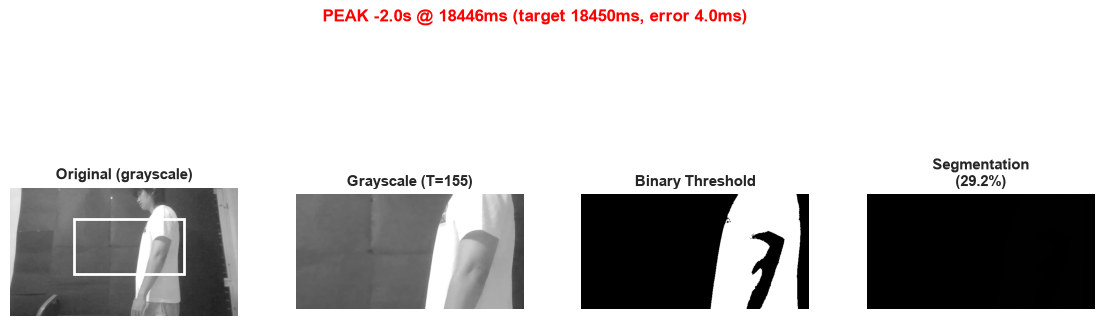

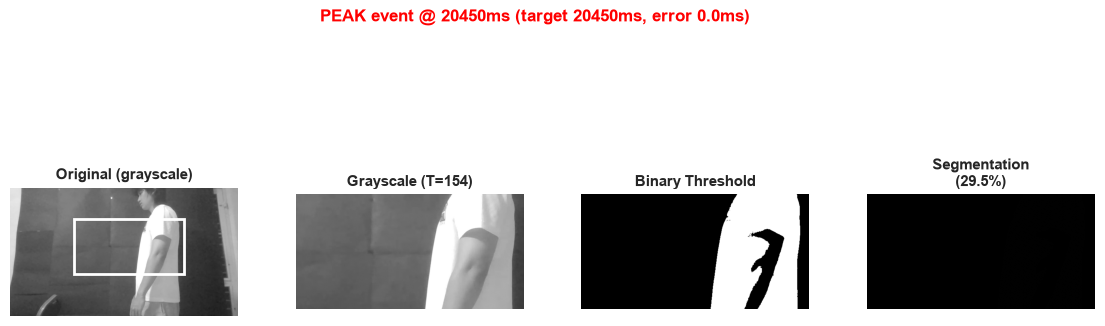

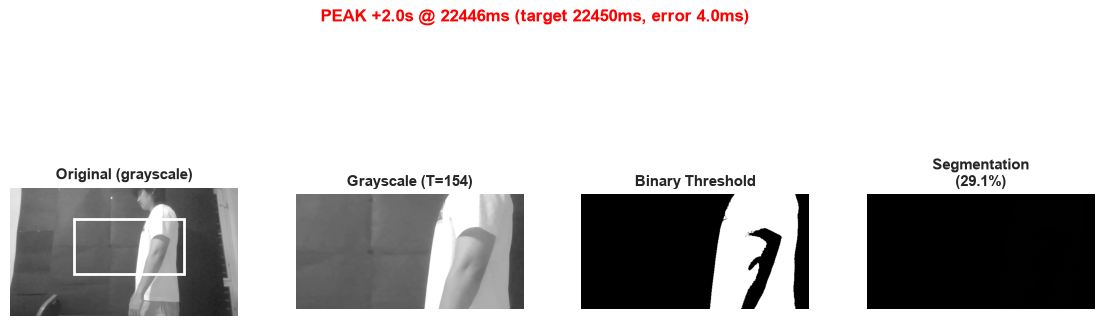

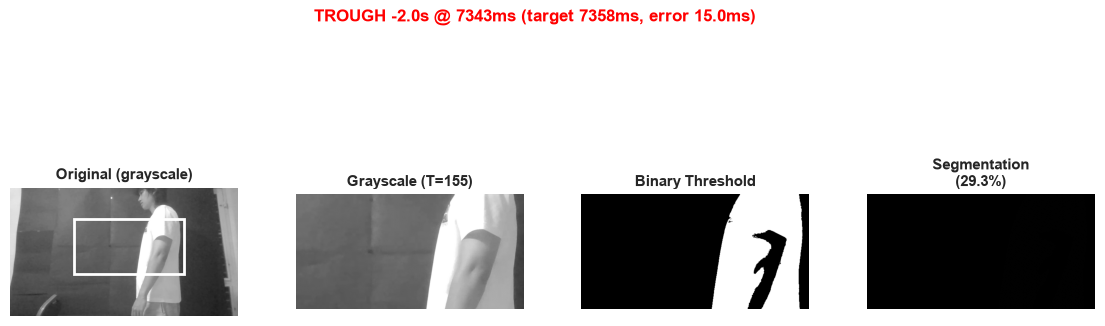

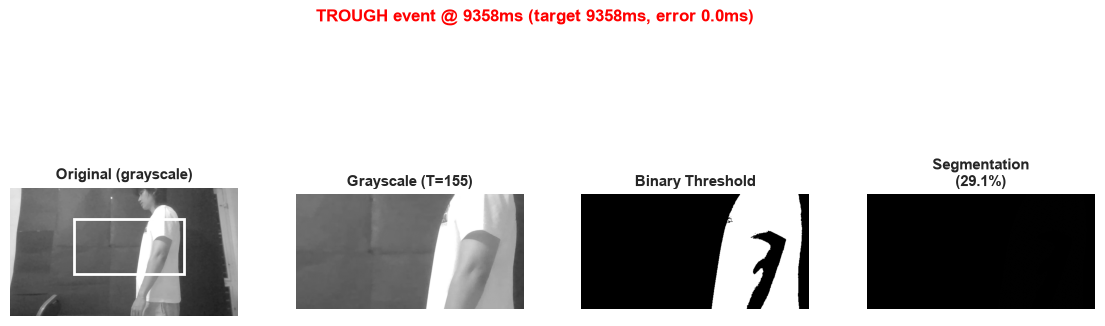

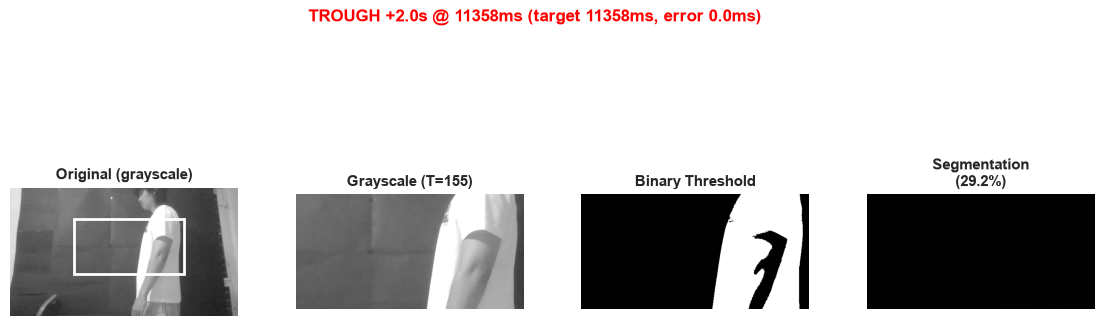

In [4]:

# Get first frame for grayscale processing visualization
for decoded in video.iter_frames():
    first_frame = decoded.frame
    break

gray = _gray_crop(first_frame, roi)
print("Running the same extraction and review pipeline as the API...")
roi, roi_source, warnings, extracted, review = review_capture(video, metadata)
analysis_roi = extracted.analysis_roi
print(f'  Search ROI: {roi}')
print(f'  Actual measurement ROI: {analysis_roi}')
print(f'  Row selection: {extracted.row_selection_method}')
threshold, dark_subject = extracted.reference_threshold, extracted.dark_subject
binary = (gray <= threshold).astype(np.uint8) * 255 if dark_subject else (gray > threshold).astype(np.uint8) * 255
mask = _subject_mask(gray, threshold, dark_subject)

print("Extracting signal from entire video...")
# extracted above with the saved locked calibration, not per-frame Otsu.
print(f"  Signal extracted: {len(extracted.raw)} frames")
filtered, display = review['waveform'], review['waveform']

from scipy.signal import find_peaks
prominence = max(float(np.std(display)) * 0.2, 1e-6)
min_distance = max(1, round(video.fps * 0.6))
peaks, peak_properties = find_peaks(display, distance=min_distance, prominence=prominence)
troughs, trough_properties = find_peaks(-display, distance=min_distance, prominence=prominence)

print(f"  Peaks detected: {len(peaks)}, Troughs: {len(troughs)}")
time_s = review['timestamps_ms'] / 1000

# Evidence is selected from phase-constrained, supported Vc levels, not RR peaks.
selected_events = [(int(np.argmin(np.abs(review['timestamps_ms']-point['ms']))), phase, 'red')
                   for phase, point in review['diagnostic']['landmarks'].items()]


def nearest_decoded_frame(target_ms):
    nearest = None
    nearest_error = float('inf')
    for decoded in video.iter_frames():
        error = abs(decoded.timestamp_ms - target_ms)
        if error < nearest_error:
            nearest = decoded
            nearest_error = error
        if decoded.timestamp_ms > target_ms and error > nearest_error:
            break
    return nearest, nearest_error


def show_event_frame(decoded, target_ms, event_name, offset_label, color, error):
    frame = decoded.frame
    frame_gray = _gray_crop(frame, roi)
    frame_threshold, frame_dark = threshold, dark_subject
    frame_binary = ((frame_gray <= frame_threshold) if frame_dark else (frame_gray > frame_threshold)).astype(np.uint8) * 255
    frame_mask = _subject_mask(frame_gray, frame_threshold, frame_dark)
    if frame_mask is None:
        frame_mask = np.zeros_like(frame_gray, dtype=np.uint8)
    selected_mask = np.zeros_like(frame_mask)
    selected_mask[extracted.selected_rows] = frame_mask[extracted.selected_rows]

    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    fig_kf = plt.figure(figsize=(18, 5))
    gs_kf = fig_kf.add_gridspec(1, 5, wspace=0.22)

    ax_orig = fig_kf.add_subplot(gs_kf[0, 0])
    ax_orig.imshow(frame_rgb)
    ax_orig.add_patch(plt.Rectangle((roi.x, roi.y), roi.width, roi.height, fill=False, edgecolor='white', linewidth=2))
    ax_orig.add_patch(plt.Rectangle((analysis_roi.x, analysis_roi.y), analysis_roi.width, analysis_roi.height, fill=False, edgecolor='lime', linewidth=2))
    ax_orig.set_title('Original color frame\nwhite: search · green: measured', fontsize=11, fontweight='bold')
    ax_orig.axis('off')

    ax_gray = fig_kf.add_subplot(gs_kf[0, 1])
    ax_gray.imshow(frame_gray, cmap='gray', vmin=0, vmax=255)
    ax_gray.axhspan(extracted.selected_rows[0], extracted.selected_rows[-1], color='lime', alpha=.18)
    ax_gray.set_title(f'Search crop (T={frame_threshold})', fontsize=11, fontweight='bold')
    ax_gray.axis('off')

    ax_bin = fig_kf.add_subplot(gs_kf[0, 2])
    ax_bin.imshow(frame_binary, cmap='gray', vmin=0, vmax=255)
    ax_bin.set_title('Raw binary threshold', fontsize=11, fontweight='bold')
    ax_bin.axis('off')

    ax_mask = fig_kf.add_subplot(gs_kf[0, 3])
    ax_mask.imshow(frame_mask, cmap='gray', vmin=0, vmax=1)
    cleanup_pixels = np.count_nonzero(frame_binary.astype(bool) != frame_mask)
    ax_mask.set_title(f'Cleaned largest-component mask\n{cleanup_pixels} pixels changed', fontsize=11, fontweight='bold')
    ax_mask.axis('off')

    ax_rows = fig_kf.add_subplot(gs_kf[0, 4])
    ax_rows.imshow(selected_mask, cmap='gray', vmin=0, vmax=1)
    mask_ratio = np.count_nonzero(selected_mask) / max(1, np.count_nonzero(frame_mask)) * 100
    ax_rows.set_title(f'Rows actually summed\n({mask_ratio:.1f}% of cleaned mask)', fontsize=11, fontweight='bold')
    ax_rows.axis('off')

    plt.suptitle(
        f'{event_name} {offset_label} @ {decoded.timestamp_ms:.0f}ms '
        f'(target {target_ms:.0f}ms, error {error:.1f}ms)',
        fontsize=12, fontweight='bold', color=color, y=0.98,
    )
    plt.tight_layout()
    plt.show()

for event_index, event_name, color in selected_events:
    event_ms = float(review['timestamps_ms'][event_index])
    for target_ms, offset_label in ((event_ms - 2000.0, '-2.0s'), (event_ms, 'event'), (event_ms + 2000.0, '+2.0s')):
        decoded, error = nearest_decoded_frame(target_ms)
        if decoded is not None:
            show_event_frame(decoded, target_ms, event_name, offset_label, color, error)

if not selected_events:
    print("\n[WARN] Not enough peaks/troughs detected")



## Step 4: Row-weighted binary image demonstration

This cell demonstrates the binary silhouette used by `_row_weighted_signal()`: each occupied row contributes its horizontal foreground width, and the row widths are summed into one signal value.


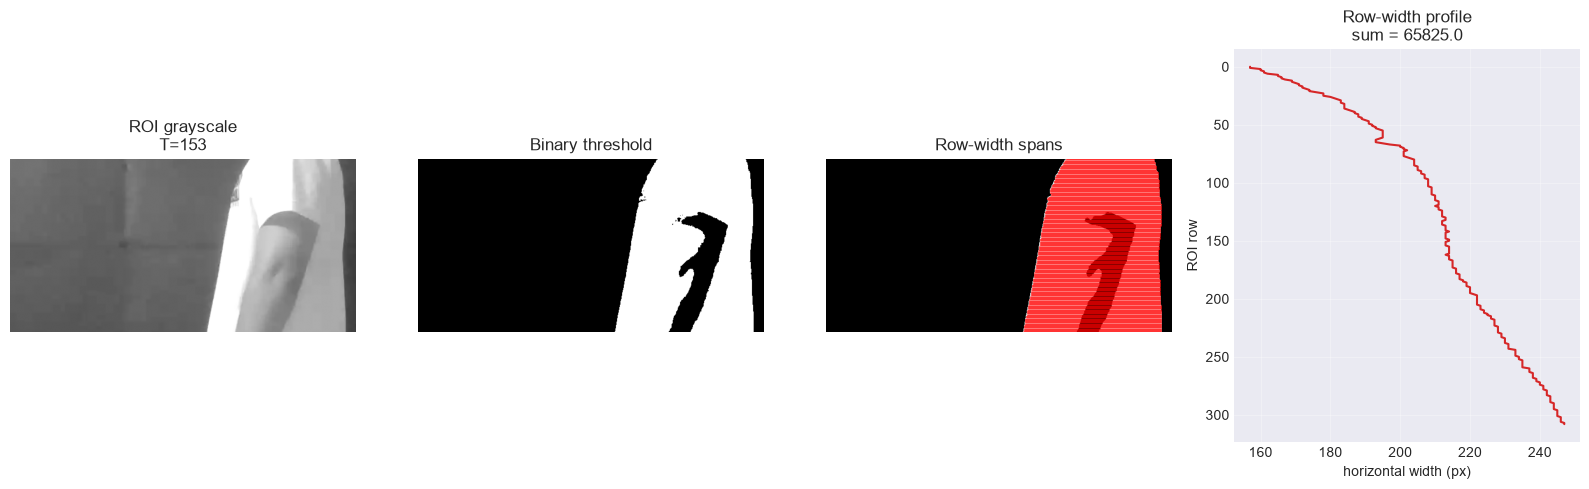

Row-weighted signal: 65825.0


In [5]:

reference_color = cv2.cvtColor(first_frame[roi.y:roi.y + roi.height, roi.x:roi.x + roi.width], cv2.COLOR_BGR2RGB)
reference_gray = _gray_crop(first_frame, roi)
reference_threshold, reference_dark = threshold, dark_subject
reference_binary = ((reference_gray <= reference_threshold) if reference_dark else (reference_gray > reference_threshold)).astype(np.uint8)
reference_mask = _subject_mask(reference_gray, reference_threshold, reference_dark)

if reference_mask is None:
    print('[WARN] No connected silhouette was found in the reference ROI.')
else:
    measurement_profile = _measurement_profile(reference_mask, reference_dark)
    profile_label = 'row width' if reference_dark else 'front-contour extent'
    weighted_signal = float(np.sum(measurement_profile[extracted.selected_rows]))

    fig, axes = plt.subplots(1, 5, figsize=(19, 5))
    axes[0].imshow(reference_color)
    axes[0].set_title('Original color ROI')
    axes[0].axis('off')

    axes[1].imshow(reference_gray, cmap='gray', vmin=0, vmax=255)
    axes[1].set_title(f'ROI grayscale\nT={reference_threshold}')
    axes[1].axis('off')

    axes[2].imshow(reference_binary * 255, cmap='gray', vmin=0, vmax=255)
    axes[2].set_title('Raw binary threshold')
    axes[2].axis('off')

    axes[3].imshow(reference_mask, cmap='gray', vmin=0, vmax=1)
    cleanup_pixels = np.count_nonzero(reference_binary.astype(bool) != reference_mask)
    for y, extent in enumerate(measurement_profile):
        if extent > 0 and y in extracted.selected_rows:
            foreground = np.flatnonzero(reference_mask[y])
            right = foreground[-1] if reference_dark else reference_mask.shape[1] - 1
            axes[3].plot([foreground[0], right], [y, y], color='red', linewidth=0.6, alpha=0.65)
    axes[3].set_title(f'Cleaned mask + selected {profile_label}\n{cleanup_pixels} pixels changed')
    axes[3].axis('off')

    axes[4].plot(measurement_profile, np.arange(len(measurement_profile)), color='tab:red', linewidth=1.2, label=profile_label)
    axes[4].axhspan(extracted.selected_rows[0], extracted.selected_rows[-1], color='limegreen', alpha=.2, label='measured band')
    axes[4].invert_yaxis()
    axes[4].set_title(f'Search ROI row profile\nselected sum = {weighted_signal:.1f}')
    axes[4].set_xlabel(f'{profile_label} (px)')
    axes[4].set_ylabel('ROI row')
    axes[4].grid(True, alpha=0.3)
    axes[4].legend(loc='best', fontsize=8)

    plt.tight_layout()
    plt.show()
    print(f'Production measurement profile ({profile_label}): {weighted_signal:.1f}')


## Method-sensitivity check: row width vs front contour

This is a counterfactual engineering check, not ground-truth validation. It decodes the same frames and holds the saved ROI, threshold, polarity, cleaned mask, selected rows, timestamps, filtering, and phase windows constant. Only the per-row measurement definition changes. A large ratio difference means clothing-specific signal extraction can materially affect Vc/Vt and needs stratified validation.


In [ ]:
# Same video + same masks + same rows; change only the row measurement definition.
method_times, width_raw, front_raw = [], [], []
method_rows = np.asarray(extracted.selected_rows, dtype=int)
for decoded in video.iter_frames():
    method_gray = _gray_crop(decoded.frame, roi)
    if method_gray is None:
        continue
    method_mask = _subject_mask(method_gray, threshold, dark_subject)
    if method_mask is None:
        continue
    width_raw.append(float(np.sum(_row_widths(method_mask)[method_rows])))
    front_raw.append(float(np.sum(_row_front_extents(method_mask)[method_rows])))
    method_times.append(decoded.timestamp_ms)

method_times = np.asarray(method_times, dtype=float)
width_raw = np.asarray(width_raw, dtype=float)
front_raw = np.asarray(front_raw, dtype=float)
method_valid_ratio = len(method_times) / max(1, video.frame_count)
review_kwargs = dict(roi_pixels=roi.width * roi.height, valid_frame_ratio=method_valid_ratio)
width_result = review_signal(width_raw, method_times, video.fps, metadata.phase_windows, **review_kwargs)
front_result = review_signal(front_raw, method_times, video.fps, metadata.phase_windows, **review_kwargs)

def method_value(result, key):
    formal = result['metrics'].get(key)
    return formal if formal is not None else result['diagnostic'].get(key)

print('Same-input method sensitivity (formal value, or diagnostic estimate when withheld)')
print(f"{'Method':22s} {'Vt (px)':>12s} {'Vc (px)':>12s} {'Vc/Vt':>12s} {'Quality':>22s}")
for label, method_result in (('row width', width_result), ('front contour', front_result)):
    vt_value = method_value(method_result, 'vt_px')
    vc_value = method_value(method_result, 'vc_px')
    ratio_value = method_value(method_result, 'ratio')
    fmt = lambda value: '--' if value is None else f'{value:.3f}'
    print(f"{label:22s} {fmt(vt_value):>12s} {fmt(vc_value):>12s} {fmt(ratio_value):>12s} {method_result['quality_status']:>22s}")
    reasons = sorted(set(method_result['diagnostic']['vt_reasons'] + method_result['diagnostic']['vc_reasons']))
    if reasons:
        print('  withheld because:', ', '.join(reasons))

width_ratio = method_value(width_result, 'ratio')
front_ratio = method_value(front_result, 'ratio')
if width_ratio is not None and front_ratio is not None and width_ratio != 0:
    print(f'Ratio difference relative to row width: {abs(front_ratio - width_ratio) / abs(width_ratio) * 100:.1f}%')

def unit_scale(values):
    values = np.asarray(values, dtype=float)
    span = np.ptp(values)
    return (values - np.min(values)) / span if span > 0 else np.zeros_like(values)

width_wave = unit_scale(width_result['waveform'])
front_wave = unit_scale(front_result['waveform'])
shape_correlation = float(np.corrcoef(width_wave, front_wave)[0, 1]) if np.std(width_wave) and np.std(front_wave) else np.nan
print(f'Normalized waveform correlation: {shape_correlation:.4f}')

method_seconds = width_result['timestamps_ms'] / 1000.0
plt.figure(figsize=(14, 4))
for phase, (start_s, end_s) in metadata.phase_windows.items():
    plt.axvspan(start_s, end_s, alpha=.07, label=phase)
plt.plot(method_seconds, width_wave, linewidth=1.4, label='Counterfactual: row width')
plt.plot(method_seconds, front_wave, linewidth=1.4, label='Counterfactual: front contour')
plt.xlabel('Decoded video time (s)')
plt.ylabel('Independently normalized signal (0-1)')
plt.title('Sensitivity to row measurement method; all other inputs held constant')
plt.grid(True, alpha=.25)
plt.legend(loc='best', ncol=2)
plt.tight_layout()
plt.show()



## Step 5

: Recalculate VT, VC, and VC/VT

Use the same filtered row-weighted signal and the saved protocol phase windows. The normal-breathing window supplies VT; the maximum-inhale and maximum-exhale windows supply VC. BPM is printed only as an additional diagnostic and is not required for the volume calculation.


In [ ]:

# Read-only replay: no database writes, same production extraction + review.
result = review_video_file(video_path, capture_metadata, declared_duration_ms)
quality = result['quality']
metric_rows = {
    'Respiratory rate (bpm)': result['rr_bpm'],
    'Tidal amplitude VT (px)': result['vt_px'],
    'Vital amplitude VC (px)': result['vc_px'],
    'VC / VT': result['ratio'],
    'Quality status (not accuracy %)': quality['status'],
    'Periodicity': quality['periodicity'],
    'Signal-band energy ratio': quality['snr'],
    'Valid frame ratio': quality['valid_frame_ratio'],
    'Temporal coherence': quality['temporal_coherence'],
}
for name, value in metric_rows.items():
    print(f'{name:31s}: {value}')

if quality['warnings']:
    print('\nWarnings:')
    for warning in quality['warnings']:
        print(' -', warning)

timestamps_s = np.asarray(result['timestamps_ms'], dtype=float) / 1000.0
waveform = np.asarray(result['waveform'], dtype=float)
plt.figure(figsize=(14, 4))
plt.plot(np.asarray(result['raw_timestamps_ms'])/1000, result['source_waveform'], color='gray', alpha=.5, label='Raw row-area')
plt.plot(timestamps_s, waveform, color='tab:blue', linewidth=1.5, label='Amplitude-preserving processed')
for phase, (start_s, end_s) in capture_metadata.get('phase_windows', {}).items():
    plt.axvspan(start_s, end_s, alpha=0.08, label=phase)
plt.xlabel('Decoded video time (s)')
plt.ylabel('Offline respiratory proxy')
plt.title('Read-only replay of the production analysis pipeline')
plt.grid(True, alpha=0.25)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()


## Production-result contract checks

These assertions test the selected real recording end to end. They verify clocks, arrays, the locked thorax band, polarity-specific signal selection, ROI containment, landmarks, and the rule that rejected values stay out of formal results. A rejection is a valid outcome; an internally inconsistent result is not.

In [ ]:
processed_times = np.asarray(result['timestamps_ms'], dtype=float)
processed = np.asarray(result['waveform'], dtype=float)
resampled_raw = np.asarray(result['raw_waveform'], dtype=float)
source_times = np.asarray(result['raw_timestamps_ms'], dtype=float)
source_values = np.asarray(result['source_waveform'], dtype=float)

assert len(processed_times) == len(processed) == len(resampled_raw) > 1
assert len(source_times) == len(source_values) > 1
assert np.all(np.isfinite(processed_times)) and np.all(np.diff(processed_times) > 0)
assert np.all(np.isfinite(source_times)) and np.all(np.diff(source_times) > 0)
assert np.all(np.isfinite(processed)) and np.all(np.isfinite(resampled_raw)) and np.all(np.isfinite(source_values))
assert 0.0 <= quality['valid_frame_ratio'] <= 1.0
assert quality['status'] in {'checks_passed', 'usable_with_caution', 'review_required'}
assert result['confidence'] is None, 'Engineering checks must not be presented as a calibrated confidence percentage.'
decode = result['diagnostics']
assert decode['width'] > 0 and decode['height'] > 0 and decode['decoded_frame_count'] > 0
capture_aspect = decode['capture_width'] / decode['capture_height']
decoded_aspect = decode['width'] / decode['height']
assert np.isclose(decoded_aspect, capture_aspect, rtol=.02), 'Decoded video is rotated, stretched, or has incompatible metadata.'

rows = np.asarray(result['selected_rows'], dtype=int)
search = result['diagnostic']['search_roi']
analysis = result['roi']
assert len(rows) > 0 and np.array_equal(rows, np.arange(rows[0], rows[-1] + 1))
assert rows[0] >= 0 and rows[-1] < search['height']
assert analysis['x'] >= search['x'] and analysis['y'] >= search['y']
assert analysis['x'] + analysis['width'] <= search['x'] + search['width']
assert analysis['y'] + analysis['height'] <= search['y'] + search['height']
assert analysis['y'] == search['y'] + int(rows[0])
assert analysis['height'] == int(rows[-1] - rows[0] + 1)

polarity = result['diagnostics']['subject_polarity']
expected_method = 'dark_row_width' if polarity == 'dark' else 'light_front_contour'
assert polarity in {'dark', 'light'}
assert result['diagnostics']['signal_method'] == expected_method
assert result['diagnostic']['signal_method'] == expected_method
assert result['diagnostic']['row_selection_method'] in {'locked_upper_thorax_vt_vc_supported_v5', 'reference_support'}
assert np.isclose(result['diagnostic']['selected_row_fraction'], len(rows) / search['height'])

windows = capture_metadata['phase_windows']
for phase, (start_s, end_s) in windows.items():
    assert np.isfinite(start_s) and np.isfinite(end_s) and 0 <= start_s < end_s, phase
diagnostic = result['diagnostic']
assert (result['vt_px'] is None) == bool(diagnostic['vt_reasons'])
assert (result['vc_px'] is None) == bool(diagnostic['vc_reasons'])
if result['ratio'] is None:
    assert result['vt_px'] is None or result['vc_px'] is None
else:
    assert result['vt_px'] > 0 and result['vc_px'] > 0
    assert np.isclose(result['ratio'], result['vc_px'] / result['vt_px'])
if result['rr_bpm'] is not None:
    assert result['vt_px'] is not None and np.isfinite(result['rr_bpm']) and result['rr_bpm'] > 0
if result['vc_px'] is not None:
    assert {'maxInhale', 'maxExhale'} <= set(diagnostic['landmarks'])

print('PASS: real-video production contract')
print(f"  {len(source_values)} decoded samples -> {len(processed)} uniform samples")
print(f"  polarity={polarity}; signal={expected_method}; selected rows={rows[0]}..{rows[-1]}")
print(f"  quality={quality['status']}; VT reasons={diagnostic['vt_reasons']}; VC reasons={diagnostic['vc_reasons']}")


## Deterministic regression tests

Synthetic signals isolate algorithm behavior from clothing, lighting, codec, and user motion. The first cell checks formal-value withholding independently for Vt and Vc. The second checks black/white polarity, the light-clothing front contour, and the fixed contiguous thorax band.

In [ ]:
def protocol_fixture():
    fps = 20.0
    seconds = np.arange(0, 38, 1 / fps)
    raw = 30000 + 100 * np.sin(2 * np.pi * .25 * seconds)
    inhale = (seconds >= 18) & (seconds < 24)
    hold = (seconds >= 24) & (seconds < 29)
    exhale = (seconds >= 29) & (seconds < 35)
    raw[inhale] = 30000 + (seconds[inhale] - 18) / 6 * 2000
    raw[hold] = 32000
    raw[exhale] = 32000 - (seconds[exhale] - 29) / 6 * 2000
    raw[seconds >= 35] = 30000
    phases = {'tidal': (3, 15), 'maxInhale': (18, 26), 'exhalePrep': (26, 29), 'maxExhale': (29, 37)}
    return raw, seconds * 1000, fps, phases

synthetic_raw, synthetic_times, synthetic_fps, synthetic_phases = protocol_fixture()
nominal = review_signal(synthetic_raw, synthetic_times, synthetic_fps, synthetic_phases)
assert nominal['quality_status'] == 'checks_passed'
assert np.isclose(nominal['metrics']['vt_px'], 200, rtol=.05)
assert np.isclose(nominal['metrics']['vc_px'], 2000, rtol=.03)
assert np.isclose(nominal['metrics']['ratio'], 10, rtol=.05)

keep_tidal_gap = ~((synthetic_times > 6000) & (synthetic_times < 8500))
missing_tidal = review_signal(synthetic_raw[keep_tidal_gap], synthetic_times[keep_tidal_gap], synthetic_fps, synthetic_phases)
assert missing_tidal['metrics']['vt_px'] is None and missing_tidal['metrics']['ratio'] is None
assert missing_tidal['metrics']['vc_px'] is not None
assert 'incomplete_tidal' in missing_tidal['diagnostic']['vt_reasons']

keep_exhale_prefix = synthetic_times < 32000
missing_exhale = review_signal(synthetic_raw[keep_exhale_prefix], synthetic_times[keep_exhale_prefix], synthetic_fps, synthetic_phases)
assert missing_exhale['metrics']['vt_px'] is not None
assert missing_exhale['metrics']['vc_px'] is None and missing_exhale['metrics']['ratio'] is None
assert 'incomplete_maxExhale' in missing_exhale['diagnostic']['vc_reasons']

flat = review_signal(np.full_like(synthetic_raw, 30000), synthetic_times, synthetic_fps, synthetic_phases)
assert flat['quality_status'] == 'review_required'
assert flat['metrics']['vt_px'] is None and flat['metrics']['vc_px'] is None and flat['metrics']['ratio'] is None
print('PASS: nominal amplitude + independent VT/VC rejection + flat-signal rejection')


In [ ]:
dark_image = np.full((100, 80), 225, dtype=np.uint8)
dark_image[10:90, 20:65] = 25
dark_threshold, dark_polarity = _threshold(dark_image)
dark_mask = _subject_mask(dark_image, dark_threshold, dark_polarity)
assert dark_polarity is True and dark_mask is not None and dark_mask[50, 40] and not dark_mask[0, 0]

light_image = np.full((100, 80), 20, dtype=np.uint8)
light_image[10:90, 20:65] = 230
light_threshold, light_polarity = _threshold(light_image)
light_mask = _subject_mask(light_image, light_threshold, light_polarity)
assert light_polarity is False and light_mask is not None and light_mask[50, 40] and not light_mask[0, 0]

torso = np.zeros((8, 40), dtype=bool)
torso[:, 10:30] = True
rear_arm = torso.copy(); rear_arm[2:6, 30:40] = True
front_expansion = torso.copy(); front_expansion[:, 6:10] = True
assert np.array_equal(_measurement_profile(torso, True), _row_widths(torso))
assert np.array_equal(_measurement_profile(torso, False), _row_front_extents(torso))
assert np.array_equal(_row_front_extents(rear_arm), _row_front_extents(torso))
assert np.sum(_row_front_extents(front_expansion) - _row_front_extents(torso)) == 32

row_fps = 10.0
row_seconds = np.arange(300) / row_fps
profiles = np.full((len(row_seconds), 100), 20.0)
band = slice(12, 40)
tidal_mask = row_seconds < 10
profiles[tidal_mask, band] += 2 * np.sin(2 * np.pi * .25 * row_seconds[tidal_mask, None])
profiles[(row_seconds >= 12) & (row_seconds < 18), band] += 8
profiles[(row_seconds >= 20) & (row_seconds < 28), band] -= 8
selected, scores, method = _select_phase_rows(
    profiles, row_seconds * 1000, np.full(100, 20.0), np.arange(100),
    {'tidal': (0, 10), 'maxInhale': (12, 18), 'maxExhale': (20, 28)}, row_fps,
)
assert method == 'locked_upper_thorax_vt_vc_supported_v5'
assert np.array_equal(selected, np.arange(12, 40))
assert np.all(scores[12:40] > scores[:12].max())
print('PASS: dark/light segmentation + light front-contour isolation + locked thorax band')


## Export for review
Run the preceding production replay first. ZIP contains Excel-readable CSV, full JSON, and an SVG chart. Exports use a unique name and never replace earlier results.

In [ ]:
from datetime import datetime, timezone
from IPython.display import display as show_link, FileLink

export_dir = backend_root / 'data' / 'exports'
export_dir.mkdir(parents=True, exist_ok=True)
stamp = datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%S%fZ')
archive_path = export_dir / f'{analysis_id}-{stamp}.zip'
archive_bytes = export_zip(result)
with ZipFile(io.BytesIO(archive_bytes)) as archive:
    assert set(archive.namelist()) == {'analysis.csv', 'analysis.json', 'waveform.svg', 'README.txt'}
    exported_json = json.loads(archive.read('analysis.json'))
    assert exported_json['export_version'] == 'went-review-export-v1'
    assert exported_json['algorithm_version'] == result['algorithm_version']
    assert exported_json['capture_metadata'] == result['capture_metadata']
    exported_csv = archive.read('analysis.csv').decode('utf-8-sig')
    assert exported_csv.startswith('kind,series,time_ms,phase,name,value,unit,quality_status')
    assert 'offline_raw' in exported_csv and 'offline_processed' in exported_csv
    exported_svg = archive.read('waveform.svg').decode('utf-8')
    ET.fromstring(exported_svg)
    assert '<polyline' in exported_svg and 'Pixel-area proxy, not liters.' in exported_svg
    assert b'Null formal metrics are withheld.' in archive.read('README.txt')
with archive_path.open('xb') as handle:
    handle.write(archive_bytes)
print('Quality:', result['quality']['status'])
print('Provisional values and reasons:', result['diagnostic'])
show_link(FileLink(str(archive_path)))
print('PASS: ZIP members, JSON, CSV, SVG XML, and README validated.')
print('CSV opens in Excel; JSON keeps metadata; SVG is a scalable chart.')
video.close()


## Full backend regression suite

This is the final gate. It runs every maintained backend test, including video decoding, ROI geometry, signal extraction, black/light clothing polarity, phase landmarks, quality withholding, storage locking, evidence selection, and single/multi-run exports.

In [ ]:
venv_python = backend_root / '.venv' / ('Scripts/python.exe' if sys.platform == 'win32' else 'bin/python')
pytest_python = str(venv_python) if venv_python.is_file() else sys.executable
completed = subprocess.run(
    [pytest_python, '-m', 'pytest', str(backend_root / 'tests'), '-q'],
    cwd=backend_root, capture_output=True, text=True,
)
print(completed.stdout)
if completed.stderr:
    print(completed.stderr)
assert completed.returncode == 0, f'Backend pytest failed with exit code {completed.returncode}'
print('PASS: complete maintained backend test suite')
